In [1]:
using ITensors
using ITensorMPS
using PolyChaos
using LinearAlgebra
using Plots
using Observers #for TDVP
using Kronecker
using SparseArrays
using ProgressMeter

include("map_functions.jl")
include("Setup.jl")
using .map_functions
using .Setup

In [63]:
#compute_Louv
#initialise_observer
#boundary_test
function compute_dΛdt(Λs,δt)
    """
    Computes derivative using simple difference formula.
    """
    dΛτ = Λs[3] - Λs[1]
    dΛτdt = dΛτ/(2*δt)
    return dΛτdt
end
function get_inv(Λτ)
    """
    Inverts Λτ, using the pseudo inverse if needed.
    """
    try
        Λτ_inv = inv(Λτ)
    catch
        Λτ_inv = pinv(Λτ)
    end
    Λτ_pinv = pinv(Λτ)
    if Id_check(Λτ*Λτ_pinv)<Id_check(Λτ*Λτ_inv)
        Λτ_inv = Λτ_pinv
    end
    return Λτ_inv
end
function Id_check(Λmat)
    """
    Returns the size of the difference between Λmat and the identity matrix.
    """
    n = size(Λmat)[1]
    Id = zeros(n,n)
    for i=1:n
        Id[i,i] = 1
    end
    return opnorm(Λmat-Id)
end
function extract_physical_modes(Ns)
    """
    Exract the elements which belong in the number block sectors of the density matrix,
    i.e. the allowed elements for a reduced density matrix for a number conserving hamiltonian.
    """

    diag_vals = diag(N_superoperator(Ns))
    qN = findall(x->x==0,diag_vals)
    return qN
end
function N_superoperator(Ns)
    """
    Number superoperator
    """
    d = 2^Ns
    Id = Diagonal(ones(Float64,d))
    Num = spin_operators(Ns)[4]
    NS = kronecker(Id,sum(Num)) - kronecker(sum(Num),Id)
    return NS
end
function compute_map_and_propagator(MPS_vec,layout,δt;kwargs...)
    """
    Given three adjacents MPS's, this returns the map calculated from the central one,
    along with the propagator calculated from all three.
    """


    take_symmetry_subset = get(kwargs,:take_symmetry_subset,false)
    ordering_choice = get(kwargs,:ordering_choice,"Separated")
    


    Λs = [calculateDynamicalMap(MPS_vec[1],layout,ordering_choice;kwargs...), 
            calculateDynamicalMap(MPS_vec[2],layout,ordering_choice;kwargs...),
            calculateDynamicalMap(MPS_vec[3],layout,ordering_choice;kwargs...)]
    

  
    Ns = length(layout.system)
    dΛτdt = compute_dΛdt(Λs,δt) 
    Λ_inv = get_inv(Λs[2])
    L =  dΛτdt*Λ_inv
    qN = extract_physical_modes(Ns)
    if take_symmetry_subset && size(Λs[2])[1] != length(qN)
        Λs[2] = Λs[2][qN,qN]
        L = L[qN,qN]
    end
    return L,Λs[2]
end
function MPS_extraction(ψ,H_MPO,TDVP_params)#,P,DP;kwargs...)

    """
    Extracts the previous and next steps of the MPS, used for the numerical derivative 
    for the propagator.
    """

    ψ1 = deepcopy(ψ)

    # Configure parameters
    updater_kwargs = Dict(:ishermitian => true, :issymmetric => true, :eager => true)
    normalize = true
    

    ψ_prev = ITensorMPS.tdvp(H_MPO, im * TDVP_params.δt, ψ; time_step = im * TDVP_params.δt, cutoff = TDVP_params.tdvp_cutoff, 
    mindim = TDVP_params.minbonddim, maxdim = TDVP_params.maxbonddim, outputlevel = 1, 
    normalize = normalize, updater_kwargs, 
    nsite = 2, reverse_step = true)

    ψ_next = ITensorMPS.tdvp(H_MPO, -im * TDVP_params.δt, ψ; time_step = -im * TDVP_params.δt, cutoff = TDVP_params.tdvp_cutoff, 
    mindim = TDVP_params.minbonddim, maxdim = TDVP_params.maxbonddim, outputlevel = 1, 
    normalize = normalize, updater_kwargs, 
    nsite = 2, reverse_step = true)

    
    MPS_vector = ψ_prev,ψ1,ψ_next
    return MPS_vector
end

function calculateDynamicalMap(ψ_input,layout,ordering_choice;kwargs...)#ψ_input,P,DP,ordering_choice;kwargs...)
    """
    Calculates the dynamical map.
    I have left the code I use the interleaved ordering in but commented out, 
    but more things in the code would have to change in order for this to work.
    """


    use_spin_operators = get(kwargs,:use_spin_operators,false)
    Ns = length(layout.system)
    s = siteinds(ψ_input)

    cdag = [op(s,"Cdag",n) for n in 1:length(ψ_input)]
    c = [op(s,"C",n) for n in 1:length(ψ_input)]


    
    if ordering_choice == "interleaved"
        println("This code needs to be modified/generalised in order for 
         an interleaved ordering to be used.")
    end
    #commented out, this code is only valid for a separated ordering choice
    # ψ = deepcopy(ψ_input)
    # if !use_spin_operators && ordering_choice == "interleaved"
    #     ##swap phases.
    #     gates =  ancilla_phase_gate_swap(layout.ancilla,Ns,c,cdag)
    #     ψ = apply_gates_to_ψ(ψ,gates)
    # end

    # if ordering_choice == "interleaved"
    #     ###Applies fermionic swap gates to change the order from interleaved to separated.
    #     ψ = system_swaps(ψ,layout.system[1],Ns,c,cdag)
    # end

    ##calculate reduced density matrix.
    rm_inds =  [layout.system;layout.ancilla]
    ρ = rdm_para(ψ_input,rm_inds,layout)

    ###applies a particle hole transformation to the ancilla states.
    gates = [cdag[n] + c[n] for n in layout.ancilla]
    ρ = apply_gates_to_ρ(ρ,gates,true)
 

    ###Convert Tensor to matrix.
    cutoff = 1e-5
    ρmat,Λmat = choi_isomorphism(ρ,layout,s)

    return Λmat
end
function ancilla_phase_gate_swap(ind,Ns,c,cdag)
    """
    Phase correction if the interleaved ordering was used
    """

    Uph_list = []
    for i =1:Ns
        for j =1:(i-1)
            x = prime(cdag[ind[j]])*c[ind[j]]*prime(c[ind[i]])*cdag[ind[i]]
            unprime_ind(inds(x)[1],x)
            unprime_ind(inds(x)[3],x)  
            Rinds = inds(x,plev=0)
            Linds = Rinds'
            Uph = exp(-im*π*x,Linds,Rinds)
            push!(Uph_list,Uph)
        end
    end
    return Uph_list
end
function system_swaps(ψ_input,start,Ns,c,cdag;kwargs...)#,DP,P;kwargs...)

    """
    This function takes a state where the system and ancilla modes are interleaved
    (with the first system mode at the start site) and swaps the ordering such that 
    indices start:start+Ns-1 are all the system modes and start+Ns:start+2Ns-1 are
    the ancilla modes.
    The index start+2(i-1) gives the site index of the ith system mode.

    """


    ψ = deepcopy(ψ_input)
    use_spin_operators = get(kwargs,:use_spin_operators,false)
    s = siteinds(ψ)

    for i=2:Ns
        for j = 1:(i-1)
            ind = start+2(i-1)-j
            ind1 = ind
            ind2 = ind+1
            swap = swap_gate(ind1,ind2,c,cdag,s;use_spin_operators)  
            orthogonalize!(ψ,ind)
            wf = (ψ[ind] * ψ[ind+1]) * swap
            noprime!(wf)
            inds3 = uniqueinds(ψ[ind],ψ[ind+1])
            U,S,V = svd(wf,inds3,cutoff=0)
            ψ[ind] = U
            ψ[ind+1] = S*V
        end
    end
    return ψ
end
function swap_gate(i,j,c,cdag,s;kwargs...)

    use_spin_operators = get(kwargs,:use_spin_operators,false)
    
    swap =  cdag[i]*c[j]+cdag[j]*c[i]
    N1 = prime(cdag[i])*c[i]
    N2 = prime(cdag[j])*c[j]
    N1_dag = prime(c[i])*cdag[i]
    N2_dag = prime(c[j])*cdag[j]

    unprime_ind(inds(N1)[1],N1)
    unprime_ind(inds(N2)[1],N2)
    unprime_ind(inds(N1_dag)[1],N1_dag)
    unprime_ind(inds(N2_dag)[1],N2_dag)  

    N = N1*N2  
    N_dag = N1_dag*N2_dag
    swap = swap + N + N_dag

    if !use_spin_operators
        Rinds = inds(N,plev=0)
        Linds = Rinds'
        fermi_fac=  exp(-im*π*N,Linds,Rinds)
        swap = swap*prime(fermi_fac)
        unprime_ind(inds(swap)[3],swap)
        unprime_ind(inds(swap)[4],swap)
    end
    return swap
end
function rdm_para(ψ_input,rm_inds,layout;kwargs...)
    """
    This function is too complicated and can definitely be greatly simplified.
    """

    # (;Ns,N_L,N_R,symmetry_subspace) = P
    # (;q,s,N,qtot) = DP

    Ns = length(layout.system)
    N_L = 2*length(layout.left_filled)
    N_R = 2*length(layout.right_filled)
    s = siteinds(ψ_input)
    N = length(s)
    qtot = 1:length(s)

    N_inds = length(rm_inds)
    left_bath_bool,right_bath_bool = N_L>0,N_R>0
    d = NDTensors.dim(s[1])

    ψ = deepcopy(ψ_input)
    ψdag = dag(ψ)
    ITensors.prime!(linkinds, ψdag)
    rdm_ = ITensor(dag(s[rm_inds]),s[rm_inds]')
    ρl =  1
    ρr =  ψdag[N]*ψ[N]

    ##Trace out left bath
    if left_bath_bool
        ρl =  ψdag[1]*ψ[1]
        left_inds = qtot[2:rm_inds[1]-1]
        for k in left_inds
            ρl = ρl* ψdag[k]
            ρl = ρl* ψ[k]
        end
    end


    ##Trace out right bath
    if right_bath_bool
        right_inds = qtot[rm_inds[end]+1:end-1]
        for k in reverse(right_inds)   
            ρr = ρr* ψdag[k]
            ρr = ρr* ψ[k]
        end
    end


    for i=0:(d^(2*N_inds) - 1)  
        #The first 2Ns (N_inds) indices are taken as s[rm_inds] and the last 2Ns (N_inds) indices are taken as s[rm_inds]'.
        ##I'm deliberately contracting ψdag[j] and ψ[j] with ρ separately to prevent creating a tensor of size
        ##χ^4 with χ being the local bond dimension. 
        ##The largest tensor created is of size \chi^2*d where d is the site dimension (2).
        v = Vector{Any}(undef,N_inds)
        w = Vector{Any}(undef,N_inds)
        
        #creating a ditstring (bitstring of base d), representing the indices of the density matrix.
        #x gives the indices of s[q], y gives the indices of s[q]'.
        ditstring = zeros(Int,2*N_inds)
        dit = reverse(digits(i,base=d))
        ditstring[(end-(length(dit))+1):end] = dit
        x = ditstring[1:N_inds] .+1
        y = ditstring[N_inds+1:end] .+1

        if QN_matching(x,y,d)
            local ρ = copy(ρl)
            b = 0
            for k in rm_inds
                b += 1
                C1 = ψ[k]*onehot(dag(s[k])=>x[b])
                C2 = ψdag[k]*onehot(s[k]=>y[b])
                ρ = ρ*C1
                ρ = ρ*C2
                v[b] = dag(s[k]) => x[b]
                w[b] = s[k]' => y[b]
            end
            ρ = ρ*ρr
            rdm_[v...,w...] = ρ[1]
        end
    end
    return rdm_
end
function apply_gates_to_ρ(ρ,gates,truncate_bool)
    """
    Applies a set of gates to the input density operator.
    """

    vector_gates_bool = isa(gates, Vector)
    vector_ρ_bool =  isa(ρ, Vector)

    if vector_gates_bool+vector_ρ_bool == 2
        println("functionality of apply_gates_to_ρ not implemented")
    end
    if vector_ρ_bool == true
        ρ_copy = gates
        gates_copy = ρ
        ρ = ρ_copy
        gates = gates_copy
    end
        
    if isa(gates, Vector)
        for i=1:length(gates)    
            if typeof(gates[i]) == MPO
                if truncate_bool
                    ρ = apply(gates[i],ρ; cutoff = 1e-15)
                    ρ = apply(ρ,gates[i]; cutoff = 1e-15)
                else
                    ρ = apply(gates[i],ρ;alg="naive",truncate=false)
                    ρ = apply(ρ,gates[i];alg="naive",truncate=false)
                end
            else
                ρ = apply(gates[i],ρ)
                ρ = apply(ρ,gates[i])
            end
        end
    elseif typeof(gates) == MPO
        if truncate_bool
            ρ = apply(gates,ρ; cutoff = 1e-15)
            ρ = apply(ρ,gates; cutoff = 1e-15)
        else
            ρ = apply(gates,ρ;alg="naive",truncate=false)
            ρ = apply(ρ,gates;alg="naive",truncate=false)
        end
    else
        ρ = apply(gates,ρ)
        ρ = apply(ρ,gates)
    end
    return ρ


end
function choi_isomorphism(ρ,layout,s)
    """
    Maps the input state as a tensor to the dynamical map as a matrix.
    """


    Ns = length(layout.system)

    d = NDTensors.dim(s[1])^Ns
    s = removeqns_mod(s)
    ρ = removeqns_mod(ρ)
    Cs = combiner(reverse(s[layout.system])) # Combiner tensor for merging system legs into a fat index
    Ca = combiner(reverse(s[layout.ancilla])) # Combiner tensor for merging ancilla legs into a fat index
    ρΛ = ρ*dag(Cs)*Cs'*dag(Ca)*Ca'# Merge physical legs to form a density matrix

    Css = combiner([inds(Cs)[1]',dag(inds(Cs)[1])])
    Caa = combiner([inds(Ca)[1]',dag(inds(Ca)[1])])
    Csa = combiner([inds(Cs)[1],inds(Ca)[1]])
    ρmat = ρΛ*dag(Csa)*Csa'
    ρmat = Matrix(ρmat,inds(ρmat));
    
    Λmat = d*ρΛ*Css*Caa
    Λmat = conj(Matrix(Λmat,inds(Λmat)));
    return ρmat,Λmat
end
function create_Choi_state(ψ_input,layout)#P,DP;kwargs...)
    
    """
    This function is a way of getting round the weird behaviour of the Jordan Wigner strings
    inside ITensor (https://itensor.discourse.group/t/are-jordan-wigner-strings-handled-in-apply/2266).
    This initialises the Choi state in separated form with no Jordan Wigner operators considered, by initialising in 
    interleaved format which doesn't implement any JW factors, then applying qubit swap gates.
    """

    """
    NOTE:interleaved_inds to reverse(interleaved_inds) was changed in January 2026.
    """

    s = siteinds(ψ_input)
    cdag = [op(s,"Cdag",n) for n in 1:length(s)]
    c = [op(s,"C",n) for n in 1:length(s)]
    q = [layout.system;layout.ancilla]
    Id = Vector{ITensor}(undef,length(s))                    #List of MPS identities
    for i =1:length(s)
        iv = s[i]
        ID = ITensor(iv', dag(iv));
        for j in 1:ITensors.dim(iv)
            ID[iv' => j, iv => j] = 1.0
        end
        Id[i] = ID
    end

    ψ = deepcopy(ψ_input)
    interleaved_inds = q[1:2:end]
    system_gate = [(cdag[n]*Id[n+1] + Id[n]*cdag[n+1])/sqrt(2) for n in reverse(interleaved_inds)]
    ψ = apply(system_gate,ψ;cutoff=1e-15)
    ψ = system_swaps(ψ,q[1],length(layout.system),c,cdag;use_spin_operators = true)

    return ψ 
end
function unprime_ind(ind,x)
    int = 1
    j = setprime(ind,int)
    replaceind!(x,ind,j)
    return x
end
function QN_matching(x,y,d)
    
    QN_x = sum(x .- 1)#QNumbers(x,d)
    QN_y = sum(y .- 1)
    if QN_x == QN_y
        return true
    else
        return false
    end

end
function removeqns_mod(x)
    try 
        x = removeqns(x)
    catch
        if typeof(x) == MPO
            x = MPO([removeqns(x[i]) for i =1:length(x)])
        elseif typeof(x) == MPS
            x = MPS([removeqns(x[i]) for i =1:length(x)])
        end
    end
    return x
end

function calculate_spectra_and_steady_state(L_vec)
    """
    Calculates spectra and steady state for each L in L_vec
    """

    spectra_vec = complex(zeros(length(L_vec),size(L_vec[1])[1])) 
    SS_vec = Vector{Any}(undef,length(L_vec))
    for i = 1:length(L_vec)
        E = eigen(L_vec[i])
        spectra_vec[i,:]= E.values
        SS_unnormalised = E.vectors[:,argmin(abs.(E.values))]

        #maps it to a matrix, divides by the trace, then maps it back to a vectorised version
        SS_normalised = vectorise_mat(unvectorise_ρ(SS_unnormalised,true))
        SS_vec[i] = SS_normalised
    end
    return spectra_vec,SS_vec
end
function lmult(A)
    """
    Super-operator representing left-multiplication on a vectorised density matrix
    """
    d = size(A)[1]
    Id = 1.0*Matrix(I, d, d)
    return kronecker(Id,A)
end
function propagate_MPS(ψ,H_MPO,obs,TDVP_params; kwargs...)
    """
    Performs time evolution on the state and computes the map and propagator is 
    compute_maps_bool ==true. Note the way this is currently done overcalculates, i.e. 
    the MPS_extraction function performs time evolutions that are already done in the main loop,
    so this can easily be improved.
    """

    #kwarg for testing if the boundary of the chain has been reached
    boundary_test_bool = get(kwargs,:boundary_test_bool,true)

    #choice of whether to calculate maps or not. Only works if the 
    #initial state is the choi state.
    compute_maps_bool = get(kwargs,:compute_maps_bool,true)

    #how many timesteps between each map calculation
    map_step = get(kwargs,:map_step,1) 
    @show(map_step)

    times = range(TDVP_params.δt,stop = TDVP_params.total_simulation_time,step = TDVP_params.δt)
    L_vec,Λ_vec,map_times = Any[],Any[],Any[],Any[]
    
    #vector to store 3 MPS' for the calculation of the propagator
    MPS_vec = Vector{Any}(undef,3)

    # Configure updater parameters
    updater_kwargs = Dict(:ishermitian => true, :issymmetric => true, :eager => true)

    #Normalisation
    ψ = ψ/norm(ψ)

    ##Enrichment
    ψt = expand(ψ,H_MPO;alg = "global_krylov")    

    global sim_t = 0

    # Main time evolution loop
    for i in 1:length(times)
        
        ψt = tdvp(H_MPO, -im * TDVP_params.δt, ψt; 
                time_step = -im * TDVP_params.δt,
                cutoff = TDVP_params.tdvp_cutoff, 
                mindim = TDVP_params.minbonddim, 
                maxdim = TDVP_params.maxbonddim, 
                outputlevel = 1, 
                observer! = obs)
        global sim_t += TDVP_params.δt
        @show(sim_t)

        if compute_maps_bool && (i % map_step == 0)
            # if ((i+1) % map_step == 0)

            #     MPS_vec[1] = ψt
            # elseif (i % map_step == 0)
            #     MPS_vec[2] = ψt
            #     push!(map_times, sim_t)

            #     #if it's the end of the simulation, an extra
            #     #timestep is done for the propagator calculation.
            #   
            #     if i == length(times)
            #         ψ3 = tdvp(H_MPO, -im * TDVP_params.δt, ψt; 
            #         time_step = -im * TDVP_params.δt,
            #         cutoff = TDVP_params.tdvp_cutoff, 
            #         mindim = TDVP_params.minbonddim, 
            #         maxdim = TDVP_params.maxbonddim, 
            #         outputlevel = 1, 
            #         observer! = obs)
            #         MPS_vec[3] = ψ3
            #         println("Time taken for map extraction")
            #         @time begin
            #             L, Λ = compute_map_and_propagator(MPS_vec,layout,TDVP_params.δt;kwargs...)
            #             push!(L_vec, L)
            #             push!(Λ_vec, Λ)
            #         end
            #     end
            # elseif ((i-1) % map_step ==0)
                
            #     MPS_vec[3] = ψt
            #     println("Time taken for map extraction")
            #     @time begin
            #         L, Λ = compute_map_and_propagator(MPS_vec,layout,TDVP_params.δt;kwargs...)
            #         push!(L_vec, L)
            #         push!(Λ_vec, Λ)
            #     end
            # end
            push!(map_times, sim_t)
            MPS_vec=  MPS_extraction(ψt,H_MPO,TDVP_params)
            println("Time taken for map extraction")
            @time begin
                L, Λ = compute_map_and_propagator(MPS_vec,layout,TDVP_params.δt;kwargs...)
                push!(L_vec, L)
                push!(Λ_vec, Λ)
            end
        end
        # Boundary condition check
        if boundary_test_bool && sum(boundary_test(ψ,ψt,layout,1e-3)) > 0
            println("Boundary reached at t = $sim_t")
        end
    end

    if compute_maps_bool
        return  ψt,obs,L_vec,Λ_vec,map_times
    else
        return ψt, obs
    end
end
function boundary_test(ψ0,ψ_evolved,layout,tol)
    """
    Tests if the boundary has been reached
    """

    N_L = length(layout.left_filled)
    N_R = length(layout.right_filled)

    left_bath_bool = N_L>0
    right_bath_bool = N_R>0
    
    
    density_op = "n"

    if left_bath_bool
        left_boundary_test = expect(ψ0,"n",sites=1) - expect(ψ_evolved,"n",sites=1)
        left_bool = abs(left_boundary_test)>tol
        if left_bool
            @show(left_boundary_test)
        end
    else 
        left_bool = false
    end
    if right_bath_bool
        right_boundary_test = expect(ψ0,density_op;sites=length(ψ0))- expect(ψ_evolved,density_op;sites=length(ψ0))
        right_bool = abs(right_boundary_test)>tol
        if right_bool
            @show(right_boundary_test)
        end
    else
        right_bool = false
    end
    return left_bool,right_bool
end
function unvectorise_ρ(ρvec,tr_bool)
    """
    Maps a vectorised density operator to a matrix, and trace
    normalises it if tr_bool==true.
    """

    d =  Int(sqrt(length(ρvec)))
    ρ = complex(zeros(d,d))
    for i =1:d
        for j=1:d
            ρ[j,i] = ρvec[Int((i-1)*d +j)]
        end
    end
    if tr_bool
        ρ = ρ/tr(ρ) ##ensures correct normalisation
    end
    return ρ
end
function vectorise_ρ(ψ,layout;kwargs...)
    """
    Calculates the reduced density matrix for the system given the MPS of the whole setup.
    Note that rdm_para is highly overcomplicated (I wrote this a while ago for a more general case) 
    and can easily be simplified.

    In order for the rdm to be valid here, the ordering of qS and qA must be separated. 
    """

    s = siteinds(ψ)

    #Creating the evolved system density matrix 
    rm_inds = layout.system
    ρ = rdm_para(ψ,rm_inds,layout;kwargs...)

    s = removeqns(s)
    ρ = removeqns(ρ)
    #combined all system legs together
    Cs = combiner(reverse(s[layout.system]))
    ρ = ρ*dag(Cs)
    ρ = ρ*Cs'
    ρ = Array(ρ,inds(ρ))
    ρvec = Vector{ComplexF64}(undef,length(ρ))
    d = size(ρ)[1]
    for i =1:d
        for j = 1:d
            ρvec[(i-1)*d + j] = ρ[j,i]
        end
    end  
    return ρvec
end
function Fock_states(s,layout;kwargs...)
    """
    Creates the fock states in the number basis.
    """


    ##given Ns sites, there are 2^Ns fock states.

    Ns = length(layout.system)
    d = NDTensors.dim(s[1])

    ##initialises an array with the same dimensions as a tensor with indices s[layout.system].
    fock_list = []
    eig_state = ITensor(s[layout.system])
    eig_state_arr = 0*Array{ComplexF64}(eig_state,s[layout.system])

    for j=0:((d^Ns)-1)
        ##This converts the index to the appropriate ditstring for the MPS index.
        inds = ones(Int,Ns)
        inds[end-length(digits(j, base=d))+1:end] = reverse(digits(j, base=d)) .+1
        fockstate = copy(eig_state_arr)
        fockstate[CartesianIndex(Tuple(inds))] = 1
        #Num = sum(x .-1) ##number occupation
        QNs = sum(inds .- 1)#QNumbers(inds,d) 
        push!(fock_list,(fockstate,QNs))
    end

    return fock_list
end
function noise_removal(ρ;kwargs...)
    """
    This function removes any numerical noise that can interfere with the diagonalisation. 
    """
    cutoff = get(kwargs,:noise_cutoff,1e-15)
    real_ρ = real.(ρ)
    imag_ρ = imag.(ρ)
    imag_ρ[abs.(imag_ρ) .< cutoff] .= 0
    real_ρ[abs.(real_ρ) .< cutoff] .= 0
    ρ = real_ρ +im*imag_ρ
    return ρ
end
function Block_submatrices(Ns,d)
    """
    Calculates the block submatrices.
    """


    Block_mats = Vector{Matrix{ComplexF64}}(undef,Ns+1) ##Vector of the block matrices
    Block_ind_vecs = Vector{Vector{Any}}(undef,Ns+1) ##Vector giving the basis of each blockmatrix in ditstrings. 
    Block_QN_vec = Vector{Int}(undef,Ns+1) ##list of QNs of the blocks
    for Num=0:Ns
        ##For Ns spinless fermionic sites, the only symmetry is number conservation. The size
        ##of the block for Num particles is given by the number of ways you can arrange Num sites in Ns sites.
        block_size = binomial(Ns,Num)
        emp_mat = complex(zeros(block_size,block_size))
        emp_vec = Vector{Any}(undef,block_size)
        Block_mats[Num+1] = emp_mat #List of empty matrices representing the allowed block matrix
        Block_ind_vecs[Num+1] = emp_vec 
        Block_QN_vec[Num+1] = Num

    end
    return Block_mats,Block_ind_vecs,Block_QN_vec
end
function rdm_to_MPS(ρ,s,layout;kwargs...)#P,DP;kwargs...)
    """
    Given a reduced density marix ρ, this function purifies it in a number conserving way
    using its eigenbasis, and initialises it as part of an MPS with thermofield occupations.

    This function is very complicated and can very likely be simplified.


    -Assuming ρ is in matrix form at this point.
    -Block_ind_vecs is a vector of vectors, where each element is the set of tensor indices that 
    relate the matrix basis of the Block matrices to the tensor basis.
    """
    # (;N_L,N_R,Ns,symmetry_subspace,bath_mode_type,ordering_choice) = P
    # (;s,q,qS,qA,N,qB_L,qB_R) = DP
    
    N_L = length(layout.left_filled)
    N_R = length(layout.right_filled)
    Ns = length(layout.system)

    Fock_list= Fock_states(s,layout)
    d = NDTensors.dim(s[1])

    ##This removes any numerical noise that can interfere with the diagonalisation. 
    ρ = noise_removal(ρ;kwargs...)

    ##Initialising vectors and tensors used later in the function
    sys_ITensor = ITensor(s[layout.system],s[layout.ancilla]) ##Tensor that will be converted to the system+ancilla part of the MPS.
    Block_mats,Block_ind_vecs,Block_QN_vec = Block_submatrices(Ns,d)
    
    num_of_sym_blocks = length(Block_ind_vecs)
    ##These are counters that track how many indices of a given symmetry block have been stored
    ind_count_rows = zeros(num_of_sym_blocks) 
    ind_count_cols = zeros(num_of_sym_blocks)


    ##loop over matrix elements of ρ and assign them to the appropriate block matrix.
    for i=1:d^(Ns)

        ##This converts the row index to the appropriate ditstring for the MPS index.
        row_inds = ones(Int,Ns)
        row_inds[end-length(digits(i-1, base=d))+1:end] = reverse(digits(i-1, base=d)) .+1
        
        ##This extracts the QNs associated with the index i, and finds the appropriate 
        ##Place to store the MPS index in Block_ind_vecs. block_index is the index
        ##of the block, but not the specific place within the block. This is given by a.

        QNs = sum(row_inds .- 1)#QNumbers(row_inds,d)
        block_index = findfirst(==(QNs),Block_QN_vec)
        ind_count_rows[block_index] += 1
        a = Int(ind_count_rows[block_index])
        Block_ind_vecs[block_index][a] =  [s[layout.system[j]] => row_inds[j] for j in 1:Ns]

        ind_count_cols[block_index] = 0 ##resets column iteration  
        for j=1:(d^Ns) 
            ##Repeats the same idea for the column index. If i and 
            ##j exists in the same symmetry block, they are assigned to 
            ##that Block in Block_mats

            col_inds = ones(Int,Ns)
            col_inds[end-length(digits(j-1, base=d))+1:end] = reverse(digits(j-1, base=d)) .+1
            if  QN_matching(row_inds,col_inds,d)
                ind_count_cols[block_index] += 1
                b = Int(ind_count_cols[block_index])
                Block_mats[block_index][a,b] = ρ[i,j]
            end
        end
    end


    for (inds,mat,QNs) in zip(Block_ind_vecs,Block_mats,Block_QN_vec)
        ##inds gives the basis of the block matrix mat.
        ###diagonalising each block matrix.
        spec_Num = noise_removal(eigen(mat).values;kwargs...)
        vecs_Num = noise_removal(eigen(mat).vectors;kwargs...)
        Block_dimension = length(spec_Num)
        
        ##These two loops loop over all the matrix elements of the matrix of eigenvectors of a given symmetry subspace, 
        ##where each eigenvector is converted to a tensor (eig_tensor) with the appropriate
        ##indices

        for j=1:Block_dimension
            eig_Tensor = ITensor(s[layout.system])
            for k =1:Block_dimension
                v = (inds)[k]
                eig_Tensor[v...] = vecs_Num[k,j]
            end

            opposite_QNs = opposite_QN(QNs,d,Ns)
            index = findfirst(Fock -> Fock[2] == opposite_QNs, Fock_list)
            anc_Tensor= ITensor((Fock_list[index])[1],s[layout.ancilla])
            splice!(Fock_list,index)
            Full_Tensor = eig_Tensor*anc_Tensor
            sys_ITensor += Full_Tensor*√(spec_Num[j])
        end
    end
    """
    We now turn sys_ITensor into an MPS with buffer sites at each end such that
    sys_MPS[[layout.system;layout.ancilla]] has open link indices at each end. We then initialise the thermal state 
    of the baths and use delta functions so they share link indices where they're combined.
    """
    left_buffer = N_L >0 ? 1 : 0
    right_buffer = N_R >0 ? 1 : 0
    buff_q = (layout.system[1]-left_buffer):(layout.ancilla[end]+right_buffer)

    if N_L>0
        sys_ITensor = diagITensor(1,s[buff_q[1]])*sys_ITensor
    end
    if N_R>0 
        sys_ITensor = sys_ITensor*diagITensor(1,s[buff_q[end]])
    end
    sys_MPS = MPS(sys_ITensor,s[buff_q])

    """
    Now sys_MPS is created, we need to initialise it within a larger MPS in a QN conserving way.
    To do this, we excite the sites from right to left, initialising the thermofield vacuum for the right bath
    and also for the system which we then overwrite with sys_MPS. Then, we apply creation operators to excite the 
    filled states in the thermofield vacuum for the left bath.
    """

    Empty = "0"
    Full = "1"
    
    left_states = ["0" for n in 1:2*N_L]
    sys_states =  [isodd(n) ? Full : Empty for n in 2*N_L+1:2*N_L+2*Ns]
    right_states =  [isodd(n) ? Full : Empty for n in 2*N_L+2*Ns+1:2*N_L+2*Ns+2*N_R]
    if N_L>0 && N_R>0
        states = [left_states;sys_states;right_states]
    elseif N_L>0 
        states = [left_states;sys_states]
    elseif N_R>0
        states = [sys_states;right_states]
    end

    therm = MPS(ComplexF64, s, states)
    sys_lk = linkinds(sys_MPS)
    therm_lk = linkinds(therm)

    if N_L >0 
        delta_L = delta(sys_lk[1],dag(therm_lk[2*N_L]))
        sys_MPS[2] = sys_MPS[2]*delta_L
    end
    if N_R >0 
        delta_R = delta(dag(sys_lk[end]),therm_lk[2*N_L+2*Ns])
        sys_MPS[end-1] = sys_MPS[end-1]*delta_R
    end

    b = N_L >0 ? 1 : 0
    for i in [layout.system;layout.ancilla]
        b += 1 
        therm[i] = sys_MPS[b]
    end
    
    for i in layout.left_filled
        O = op("Cdag",s[i])
        therm = apply(O,therm)
    end
    
    return therm 
end
function JW_string(n,start,s)
    """
    Creates a string of JW operators.
    """

    F = ops(s, [("F", n) for n in 1:length(s)])
    if n>start
        x = F[n-1]
        if n-1>start
            for i in reverse(start:n-2)
                x = F[i]*x
            end
        end
    else
        x=1
    end
    return x
end 
function Id_string(n1,n2,s)
    """
    Gives an Id string from n1+1 to n2. Note that
    these operators don't need to be applied in a specific order as they
    all commute with everything. 
    """


    Id = Vector{ITensor}(undef,length(s))     #List of MPS identities
    for i =1:length(s)
        iv = s[i]
        ID = ITensor(iv', dag(iv));
        for j in 1:ITensors.dim(iv)
            ID[iv' => j, iv => j] = 1.0
        end
        Id[i] = ID
    end

    x=1
    for i =n1+1:n2
        x = Id[i]*x
    end
    return x
end
function create_fermi_ann_op(site,subsys_inds,c,s) 
    """
    Manually creates a fermionic annihilation operator
    """
    return JW_string(site, subsys_inds[1],s) * c * Id_string(site, subsys_inds[end],s) 
end
function create_fermi_cre_op(site,subsys_inds,cdag,s)
    """
    Manually creates a fermionic creation operator
    """
    return JW_string(site, subsys_inds[1],s) * cdag * Id_string(site, subsys_inds[end], s) 
end
function spin_operators(M)

    # Build sparse matrix version of basic spin (Pauli) operators :
    sp = spdiagm(2,2,1=>ones(1))
    sm = spdiagm(2,2,-1=>ones(1))
    sz = spdiagm(2,2,0=>[1;-1]);
    num = spdiagm(2,2,0=>[0;1])
    # Notice there are NO factors of (1/2) for spin-1/2 included here.

    # Construct spin operators for each spin in the full Hilbert space :
    Sz = Vector{Any}(undef, M)
    Sp = Vector{Any}(undef, M)
    Sm = Vector{Any}(undef, M)
    Num = Vector{Any}(undef,M)
    for m=1:M
        Sz[m] = kronecker(kronecker(spdiagm(2^(m-1),2^(m-1),0=>ones(2^(m-1))),sz),spdiagm(2^(M-m),2^(M-m),0=>ones(2^(M-m))));
        Sp[m] = kronecker(kronecker(spdiagm(2^(m-1),2^(m-1),0=>ones(2^(m-1))),sp),spdiagm(2^(M-m),2^(M-m),0=>ones(2^(M-m))));
        Sm[m] = kronecker(kronecker(spdiagm(2^(m-1),2^(m-1),0=>ones(2^(m-1))),sm),spdiagm(2^(M-m),2^(M-m),0=>ones(2^(M-m))));
        Num[m] = kronecker(kronecker(spdiagm(2^(m-1),2^(m-1),0=>ones(2^(m-1))),num),spdiagm(2^(M-m),2^(M-m),0=>ones(2^(M-m))));
    end
    return Sz,Sp,Sm,Num
end
function JW_string_mat(Sz,site,M;kwargs...)
    """
    Creates the JW_string as a single matrix, i.e. not a tensor.
    """
    inds = get(kwargs,:inds,1:(site-1))

    Z = 1.0*Matrix(I, 2^M, 2^M)
    for i in inds
        Z = Z*Sz[i];
    end
    return Z
end
function matrix_operators(number_of_modes)
    """
    Creates fermionic creation and annhilation operators as full matrices.
    """

    Sz,Sp,Sm,_ = spin_operators(number_of_modes)
    cdag_mat = Vector{Any}(undef,number_of_modes)
    c_mat = Vector{Any}(undef,number_of_modes)

    for n=1:number_of_modes
        #Build JW_string
        Z = JW_string_mat(Sz,n,number_of_modes)
        cdag_mat[n] = Z*Sm[n]
        c_mat[n]  = Z*Sp[n]
    end
    return cdag_mat,c_mat
end  
function vectorise_ρ(ket_input,bra_input,layout;kwargs...)
    """
    Calculates the reduced density matrix for the two input states.
    Note that rdm_para is highly overcomplicated (I wrote this a while ago for a more general case) 
    and can easily be simplified.


    In order for the rdm to be valid here, the ordering of layout.system and layout.ancilla must be separated. 
    Rather than just calculating the reduced density matrix of |ψ><ψ|, this allows the reduced density matrix of |ψ><ϕ|.

    """
    

    rdm_block_sparse_bool = get(kwargs,:rdm_block_sparse_bool,true)
    ψ_ket = deepcopy(ket_input)
    ϕ_bra = deepcopy(bra_input)
    s = siteinds(ket_input)


    #Creating the evolved system density matrix 
    rm_inds = layout.system
    if !rdm_block_sparse_bool
        ψ_ket = removeqns_mod(ψ_ket)
        ϕ_bra = removeqns_mod(ϕ_bra)
    end
    ρ = rdm_para(ψ_ket,ϕ_bra,rm_inds,layout;kwargs...)

    s = removeqns(s)
    ρ = removeqns(ρ)
    #combined all system legs together
    Cs = combiner(reverse(s[layout.system]))

    ρ = ρ*dag(Cs)
    ρ = ρ*Cs'
    ρ = Array(ρ,inds(ρ))
    ρvec = Vector{ComplexF64}(undef,length(ρ))
    d = size(ρ)[1]
    for i =1:d
        for j = 1:d
            ρvec[(i-1)*d + j] = ρ[j,i]
        end
    end  
    return ρvec
end
function rdm_para(ψ_input,ϕ_input,rm_inds,layout;kwargs...)
    """
    This function is too complicated and can definitely be greatly simplified.


    Rather than just calculating the reduced density matrix of |ψ><ψ|, this
    allows the reduced density matrix of |ψ><ϕ|.
    """

    # (;Ns,N_L,N_R,symmetry_subspace) = P
    # (;q,s,N,qtot) = DP
    rdm_block_sparse_bool = get(kwargs,:rdm_block_sparse_bool,true)

    Ns = length(layout.system)
    N_L = 2*length(layout.left_filled)
    N_R = 2*length(layout.right_filled)
    s = siteinds(ψ_input)
    N = length(s)
    qtot = 1:length(s)

    
    ψ = deepcopy(ψ_input)
    ϕ = deepcopy(ϕ_input)

    ###This is needed for doing the greens function calculation where ψ and ϕ
    ##have different QNs
    if !rdm_block_sparse_bool
        s = removeqns_mod(s)
    end


    N_inds = length(rm_inds)
    left_bath_bool,right_bath_bool = N_L>0,N_R>0
    d = NDTensors.dim(s[1])
    ϕdag = dag(ϕ)
    ITensors.prime!(linkinds, ϕdag)
    rdm_ = ITensor(dag(s[rm_inds]),s[rm_inds]')
    ρl =  1
    ρr =  ϕdag[N]*ψ[N]

    ##Trace out left bath
    if left_bath_bool
        ρl =  ϕdag[1]*ψ[1]
        left_inds = qtot[2:rm_inds[1]-1]
        for k in left_inds
            ρl = ρl* ϕdag[k]
            ρl = ρl* ψ[k]
        end
    end

    ##Trace out right bath
    if right_bath_bool
        right_inds = qtot[rm_inds[end]+1:end-1]
        for k in reverse(right_inds)   
            ρr = ρr* ϕdag[k]
            ρr = ρr* ψ[k]
        end
    end

    for i=0:(d^(2*N_inds) - 1)  
        #The first 2Ns (N_inds) indices are taken as s[q] and the last 2Ns (N_inds) indices are taken as s[q]',
        #where q are indices of system and ancilla combined.
        ##I'm deliberately contracting ψdag[j] and ψ[j] with ρ separately to prevent creating a tensor of size
        ##χ^4 with χ being the local bond dimension. 
        ##The largest tensor created is of size \chi^2*d where d is the site dimension (2).
        v = Vector{Any}(undef,N_inds)
        w = Vector{Any}(undef,N_inds)
        
        #creating a ditstring (bitstring of base d), representing the indices of the density matrix.
        #x gives the indices of s[q], y gives the indices of s[q]'.
        ditstring = zeros(Int,2*N_inds)
        dit = reverse(digits(i,base=d))
        ditstring[(end-(length(dit))+1):end] = dit
        x = ditstring[1:N_inds] .+1
        y = ditstring[N_inds+1:end] .+1

        if rdm_block_sparse_bool 
            matrix_element_bool = QN_matching(x,y,d)
        else
            matrix_element_bool = true 
        end

        if matrix_element_bool
            local ρ = copy(ρl)
            b = 0
            for k in rm_inds
                b += 1
                C1 = ψ[k]*onehot(dag(s[k])=>x[b])
                C2 = ϕdag[k]*onehot(s[k]=>y[b]) 
                ρ = ρ*C1
                ρ = ρ*C2
                v[b] = dag(s[k]) => x[b]
                w[b] = s[k]' => y[b] 
            end
            ρ = ρ*ρr

            rdm_[v...,w...] = ρ[1]
        end
    
    end
    return rdm_
end
function QN_matching(x,y,d)
        
    """
    Calculates the total number of the input state as a ditstring.
    """

    QN_x = sum(x .- 1)#QNumbers(x,d)
    QN_y = sum(y .- 1)
    if QN_x == QN_y
        return true
    else
        return false
    end

end
function opposite_QN(QN,d,Ns)
    """
    Assumes spinless fermions
    """
    ##maximum Num is Ns
    return Int(Ns - QN)
end
function vectorise_mat(mat)
    "Takes a matrix and vectorises it according to the Choi-Jamiolkowski ispmorphism."
    d =  size(mat)[1]
    vec = complex(zeros(Int(d*d)))
    for i =1:d
        for j=1:d
            vec[Int((i-1)*d +j)] = mat[j,i]
        end
    end
    return vec
end
function map_check(ψf,ψi,Λmat,layout)
    ρf = vectorise_ρ(ψf,layout)
    ρi = vectorise_ρ(ψi,layout)
    return norm(ρf - Λmat*ρi)
end


map_check (generic function with 1 method)

In [2]:

"""
Define parameters
"""

left_bath = BathParameters(Γ = 0.05,β = 10.0,μ = 0.1,D = 1.0,N =0)

right_bath = BathParameters(Γ = 0.05,β = 10.0,μ = -0.1,D = 1.0,N = 10)

system = SystemParameters(ϵ = [0.0,0.0],t = [0.1],U = [0.0],occupations=["Emp","Emp"])

layout =ChainLayout(left_bath.N,right_bath.N,length(system.ϵ))

TDVP_params = TDVP_parameters(tdvp_cutoff = 1e-10,minbonddim = 10,maxbonddim = 40,δt = 0.1,total_simulation_time = 10)

times = range(TDVP_params.δt,stop = TDVP_params.total_simulation_time,step = TDVP_params.δt)

"""
Create initial MPS
"""
sites = siteinds("Fermion",2*left_bath.N+2*right_bath.N + 2*length(system.ϵ);conserve_qns=true)
initial_occupations = thermofield_state(left_bath,right_bath,system)
ψ0 = MPS(ComplexF64,sites,initial_occupations)
ψ0 = create_Choi_state(ψ0,layout);

Λi = calculateDynamicalMap(ψ0,layout,"separated")

"""
Create single particle Hamiltonian and many-body MPO
"""

H_MPO,Hsingle =build_hamiltonian(sites,left_bath,right_bath,system);
"""
TDVP
"""

#create observer for tdvp
obs = Observer("times" => current_time,"corr" => measure_correlation_matrix)

#enrichment, needed to reduce initial projection error
ψ = expand(ψ0,H_MPO;alg = "global_krylov")   ; 

# Λ_vec = Vector{Any}(undef,length(times))
# for i=1:length(times)
#     ψ = tdvp(H_MPO, -im * TDVP_params.δt, ψ; 
#     time_step = -im * TDVP_params.δt,
#     cutoff = TDVP_params.tdvp_cutoff, 
#     mindim = TDVP_params.minbonddim, 
#     maxdim = TDVP_params.maxbonddim, 
#     outputlevel = 1, 
#     observer! = obs)
#     Λ_vec[i] = calculateDynamicalMap(ψ,layout,"separated")

# end

# spectra_Λ = complex(zeros(length(Λ_vec),2^(2*length(layout.system))))
# [spectra_Λ[i,:] = eigen(Λ_vec[i]).values for i=1:length(Λ_vec)] 
# display(Plots.plot(times,real.(spectra_Λ),ms=0.1,label=false))


24-element MPS:
 ((dim=2|id=970|"Fermion,Site,n=1") <Out>
 1: QN("Nf",0,-1) => 1
 2: QN("Nf",1,-1) => 1, (dim=6|id=13|"sum") <Out>
 1: QN("Nf",11,-1) => 1
 2: QN("Nf",12,-1) => 1
 3: QN("Nf",11,-1) => 2
 4: QN("Nf",12,-1) => 2)
 ((dim=2|id=970|"Fermion,Site,n=2") <Out>
 1: QN("Nf",0,-1) => 1
 2: QN("Nf",1,-1) => 1, (dim=12|id=301|"sum") <Out>
 1: QN("Nf",10,-1) => 1
 2: QN("Nf",11,-1) => 2
 3: QN("Nf",12,-1) => 1
 4: QN("Nf",10,-1) => 2
 5: QN("Nf",11,-1) => 4
 6: QN("Nf",12,-1) => 2, (dim=6|id=13|"sum") <In>
 1: QN("Nf",11,-1) => 1
 2: QN("Nf",12,-1) => 1
 3: QN("Nf",11,-1) => 2
 4: QN("Nf",12,-1) => 2)
 ((dim=2|id=309|"Fermion,Site,n=3") <Out>
 1: QN("Nf",0,-1) => 1
 2: QN("Nf",1,-1) => 1, (dim=9|id=895|"sum") <Out>
 1: QN("Nf",10,-1) => 1
 2: QN("Nf",11,-1) => 1
 3: QN("Nf",10,-1) => 3
 4: QN("Nf",11,-1) => 3
 5: QN("Nf",12,-1) => 1, (dim=12|id=301|"sum") <In>
 1: QN("Nf",10,-1) => 1
 2: QN("Nf",11,-1) => 2
 3: QN("Nf",12,-1) => 1
 4: QN("Nf",10,-1) => 2
 5: QN("Nf",11,-1) => 4
 6: 

In [3]:
function multitime_correlators_using_NMQMpE_using_MPS(ψ0,H_MPO,τmL1,τmL2,τmL3,TDVP_params,end_time,site;kwargs...)

    """
    Step 1: Obtain converged objects
    -(a): Obtain L(τmL) and Λ(τmL) and L(τmL)'s zero eigenvalue, ρ∞
    -(b): Obtain ρf

    Step 2: Simulations using whole system and bath
    -(a): Evolve full system and bath density matrix, starting from the state
    ρ_tot(0) = ρf⊗ρ_B(0) up to time τmL. By construction,
    Tr_{B}(ρ_tot(τmL)) = ρ∞, where ρ_tot(τmL)= e^(-iHτmL)*ρ_tot(0)*e^(iHτmL).
    -(b): Create 2 new MPSs,  ϕ_L_greater=cdag|ρf(τmL)> and ϕ_L_greater=c|ρf(τmL)>.
    -(c): Evolve cdag|ρf(τmL)>,c|ρf(τmL)>,|ρf(τmL)> again by the full Hamiltonian, 
    up to time τmL.

    # Step 3: Only requires matrix multiplications in system Hilbert space
    # -(a): Trace out the bath to obtain \tilde{ρ}(τmL) = Tr_B(\tilde{ρ}_tot(τmL))
    # -(b): Obtain \tilde{ρ}(τ) = e^((τ-τmL)L)*\tilde{ρ}(τmL).
    
    
    Possible kwarg inputs:
    -τmL: the (guessed) memory time of the propagator. If not specified it will default to P.T.
    -use_spin_operators: boolean that decides whether to do the map calculation and rdms using 
    spin operators or fermionic operators (with appropriate corrections). Defaults to false.
    -take symmetry_subset: decides whether to only include the physically allowed matrix elements for the maps,
    defaults to true.
    -TDVP_nsite: defaults to 2.
    -enrich_bool: a boolean that decides whether to enrich every n*δt steps
    -cutoff: used for removal of noise for rdm_to_MPS, defaults to 1e-15
    """

    times1 = range(TDVP_params.δt,stop=τmL1,step = TDVP_params.δt)
    times2 = range(TDVP_params.δt,stop=τmL2,step = TDVP_params.δt) 
    TDVP_nsite = get(kwargs, :TDVP_nsite, 2)
    enrich_bool = get(kwargs,:enrich_bool,true)
    #take_symmetry_subset = get(kwargs,:take_symmetry_subset,false)
    ordering_choice = get(kwargs,:ordering_choice,"separated")
    use_spin_operators = get(kwargs,:use_spin_operators,false)
    plotting_bool = get(kwargs,:plotting_bool,false)
    memory_time_ind = get(kwargs,:memory_time_ind,false)
    @assert(end_time >= τmL2+τmL3)


    #Checking identity map
    Λi = calculateDynamicalMap(ψ0,layout,ordering_choice;use_spin_operators=false)
    @show(Id_check(Λi))

    #Step 1
    println("
    #######################################################################
    Time evolution to calculate maps, propagators and steady state.
    #######################################################################")
    

    #create observer for tdvp
    obs = Observer("times" => current_time,"corr" => measure_correlation_matrix)

    TDVP_params.total_simulation_time= τmL1
    ψ,map_calc_obs,L_vec,Λ_vec,map_times =  propagate_MPS(ψ0,H_MPO,obs,TDVP_params;compute_maps_bool=true, kwargs...)

    spectra_vec,SS_vec = calculate_spectra_and_steady_state(L_vec)
    if plotting_bool
        display(Plots.plot(map_times,real.(spectra_vec),title="Real part of spectra of the propagator",xlabel="τD"))
    end

    #gives an option to choose the specific point where the fast state is calculated
    if memory_time_ind == false
        Lτm,Λτm,steady_state = L_vec[end],Λ_vec[end],SS_vec[end]
    else
        Lτm,Λτm,steady_state = Lτm,[Int(memory_time_ind)],Λ_vec[Int(memory_time_ind)],SS_vec[Int(memory_time_ind)]
    end


    @show(map_check(ψ,ψ0,Λτm,layout))

    # if take_symmetry_subset
    #     ρf= unvectorise_ρ(expand_Λ(pinv(Λτm),P.Ns)*NESS,true)
    # else
    ρf= unvectorise_ρ(pinv(Λτm)*steady_state,true)
    #if ρf is unphysical, this finds one that is
    if sum(real.(eigen(ρf).values) .<0) > 0
        ρf_bool = false
        for i =reverse(1:length(L_vec))
            spec = eigen(L_vec[i]).values
            vecs = eigen(L_vec[i]).vectors
            steady_state_i = vecs[:,argmin(abs.(spec))]
            ρf_test = unvectorise_ρ(pinv(Λ_vec[i])*steady_state_i,true)
            if sum(real.(eigen(ρf).values) .<0) == 0
                ρf = ρf_test   
                ρf_bool = true
            end
        end
        if ρf_bool == false
            ρf = unvectorise_ρ(steady_state,true)
        end
    end  


    if ordering_choice == "interleaved"
        println("
        For the purified MPS to give the fast state after 
        tracing out, the ancillas must be contiguous. So, if
        an interleaved system-ancilla setup was used to calculate the 
        map, then this must be switched at this point. This code assumes a separated ordering
        is used at all times to avoid this complication, so using an interleaved ordering
        is not currently implemented")
    end

    #creating an MPS that defines the purified ρf
    ρf_MPS = rdm_to_MPS(ρf,siteinds(ψ),layout)

    #testing it gives the fast state after tracing out
    ρf_test = vectorise_ρ(ρf_MPS,layout)

    
    @show(norm(ρf_test-vectorise_mat(ρf)))

    println("
    #######################################################################
    Time evolution towards stationarity, starting with ρf
    #######################################################################")
    #Step 2

    #create observer for tdvp
    obs = Observer("times" => current_time,"corr" => measure_correlation_matrix)

    TDVP_params.total_simulation_time = τmL2
    ρf_MPS_evolved,SS_prep_obs=  propagate_MPS(ρf_MPS,H_MPO,obs,TDVP_params;compute_maps_bool = false,kwargs...)
    
    #save_object("ρf_MPS_evolved.jld2",ρf_MPS_evolved)

    #some plotting showing the thermalisation
    corrs = SS_prep_obs.corr
    den_vec = [corr[site,site] for corr in corrs]
    if plotting_bool
        display(Plots.plot(times2,real.(den_vec),label="density"))
    end

        
    ρf_evolved_mat = vectorise_ρ(ρf_MPS_evolved,layout)
    #Test to show if ρf gives the steady state after the evolution
    # if take_symmetry_subset
    #     @show(norm(ρf_evolved_mat-expand_Λ(Λτm,P.Ns)*ρf_test))
    # else
    @show(norm(ρf_evolved_mat-Λτm*ρf_test))
    @show(norm(steady_state-ρf_evolved_mat))


    println("
    #######################################################################
    Once stationary the state is perturbed with the appropriate 
    creation/annihilation operators for the greens function calulations.
    #######################################################################")
    ##Creating ϕ_L_greater, ϕ_R_greater, ϕ_L_lesser and ϕ_R_lesser
    ##ϕ_R_greater and ϕ_L_lesser are calculated from ϕ=U(t)*ρf_evolved
    ϕ = deepcopy(ρf_MPS_evolved)

    s = siteinds(ϕ)
    ϕ_L_greater = apply(create_fermi_cre_op(layout.system[site],[layout.system;layout.ancilla],op(s,"Cdag",layout.system[site]),s),ϕ)
    ϕ_R_lesser = apply(create_fermi_ann_op(layout.system[site],[layout.system;layout.ancilla],op(s,"C",layout.system[site]),s),ϕ)

    Nsteps = Int(end_time/TDVP_params.δt)
    Grn_t = zeros(ComplexF64, Nsteps+1)
    Grn_lesser,Grn_greater = similar(Grn_t),similar(Grn_t)
    Grn_t[1] = -1.0*im ##t=0 value
    Grn_t_test = deepcopy(Grn_t)

    println("
    #######################################################################
    The three MPSs required for the greens function are propagated for a time
    τmL, after which their evolution can be described by propagation
    with the fixed propagator.
    #######################################################################")
    # Configure updater parameters
    updater_kwargs = Dict(:ishermitian => true, :issymmetric => true, :eager => true)
    sim_t = 0
    no_of_tdvp_steps = Int(τmL3/TDVP_params.δt)


    cdag_mat,c_mat = matrix_operators(length(layout.system))
    ρ_tilde_lesser_vec = Vector{Any}(undef,Nsteps+1)
    ρ_tilde_greater_vec = Vector{Any}(undef,Nsteps+1)
    ρ_tilde_lesser_vec[1] = vectorise_ρ(ϕ,ϕ_R_lesser,layout;rdm_block_sparse_bool = false,kwargs...)
    ρ_tilde_greater_vec[1] = vectorise_ρ(ϕ_L_greater,ϕ,layout;rdm_block_sparse_bool = false,kwargs...)

    
    for i =1:(no_of_tdvp_steps)
        ϕ_L_greater= tdvp(H_MPO,-im * TDVP_params.δt,ϕ_L_greater; time_step = -im * TDVP_params.δt, cutoff = TDVP_params.tdvp_cutoff,
        mindim=TDVP_params.minbonddim,maxdim=TDVP_params.maxbonddim,outputlevel=1, normalize=false,updater_kwargs, reverse_step = true)
    
        ϕ_R_lesser = tdvp(H_MPO,-im * TDVP_params.δt,ϕ_R_lesser; time_step = -im * TDVP_params.δt, cutoff = TDVP_params.tdvp_cutoff,
        mindim=TDVP_params.minbonddim,maxdim=TDVP_params.maxbonddim,outputlevel=1, normalize=false,updater_kwargs,reverse_step = true)

        ϕ = tdvp(H_MPO,-im * TDVP_params.δt,ϕ; time_step = -im * TDVP_params.δt, cutoff = TDVP_params.tdvp_cutoff,
        mindim=TDVP_params.minbonddim,maxdim=TDVP_params.maxbonddim,outputlevel=1, normalize=true,updater_kwargs,reverse_step = true)
        
        ##Calculating ϕ_R_greater and ϕ_L_lesser
        ϕ_R_greater = apply(create_fermi_cre_op(layout.system[site],[layout.system;layout.ancilla],op(s,"Cdag",layout.system[site]),s),ϕ)
        ϕ_L_lesser = apply(create_fermi_cre_op(layout.system[site],[layout.system;layout.ancilla],op(s,"C",layout.system[site]),s),ϕ)

        Grn_lesser[i+1] = im*inner(ϕ_R_lesser,ϕ_L_lesser)
        Grn_greater[i+1] = -im*inner(ϕ_R_greater,ϕ_L_greater)
        Grn_t[i+1] = Grn_greater[i+1]-Grn_lesser[i+1]

        ρ_tilde_lesser = vectorise_ρ(ϕ,ϕ_R_lesser,layout;rdm_block_sparse_bool = false,kwargs...) 
        ρ_tilde_greater= vectorise_ρ(ϕ_L_greater,ϕ,layout;rdm_block_sparse_bool = false,kwargs...)
        G_greater = -im*tr(c_mat[site]*unvectorise_ρ(ρ_tilde_greater,false))
        G_lesser = im*tr(c_mat[site]*unvectorise_ρ(ρ_tilde_lesser,false))
        Grn_t_test[i+1] = G_greater-G_lesser

        ρ_tilde_lesser_vec[i+1] = ρ_tilde_lesser
        ρ_tilde_greater_vec[i+1] = ρ_tilde_greater
        sim_t += TDVP_params.δt
        @show(sim_t)
    end

    ρ_tilde_lesser = ρ_tilde_lesser_vec[no_of_tdvp_steps+1]
    ρ_tilde_greater = ρ_tilde_greater_vec[no_of_tdvp_steps+1]

    println("
    #######################################################################
    After τmL, ρ_tilde_lesser and ρ_tilde_greater are calculated and are 
    propagated using the converged propagator.
    #######################################################################")
    
    #Applies parity correction
    Sz = spin_operators(length(layout.system))[1]
    parity_op = Matrix(Sz[1])
    for i=2:length(layout.system)
        parity_op *= Matrix(Sz[i])
    end
    parity_op_vec = lmult(parity_op)
    Lbar_τm = parity_op_vec*Lτm*parity_op_vec

    remaining_steps = Int((end_time-τmL3)/TDVP_params.δt)
    for i = 1:remaining_steps
        ρ_tilde_lesser = exp(Lbar_τm*TDVP_params.δt)*ρ_tilde_lesser
        ρ_tilde_greater = exp(Lbar_τm*TDVP_params.δt)*ρ_tilde_greater

        Grn_greater[no_of_tdvp_steps+i+1] = -im*tr(c_mat[site]*unvectorise_ρ(ρ_tilde_greater,false))
        Grn_lesser[no_of_tdvp_steps+i+1] = im*tr(c_mat[site]*unvectorise_ρ(ρ_tilde_lesser,false))
        Grn_t[no_of_tdvp_steps+i+1] = Grn_greater[no_of_tdvp_steps+i+1]-Grn_lesser[no_of_tdvp_steps+i+1]
    end
    
    total_times = range(0,stop=end_time,step=TDVP_params.δt)
    output_dict = Dict()
    output_dict["Grn_t"] = Grn_t
    output_dict["Grn_lesser"] = Grn_lesser
    output_dict["Grn_greater"] = Grn_greater
    output_dict["total_times"] = total_times
    output_dict["L_vec"] = L_vec
    output_dict["Λ_vec"] = Λ_vec
    output_dict["SS_prep_obs"] = SS_prep_obs
    output_dict["map_calc_obs"] = map_calc_obs
    output_dict["ρf_MPS"] = ρf_MPS
    output_dict["ρf_MPS_evolved"] = ρf_MPS_evolved
    output_dict["ρ_tilde_lesser"] = ρ_tilde_lesser
    output_dict["ρ_tilde_greater"] = ρ_tilde_greater
    output_dict["τmLs"] = [τmL1,τmL2,τmL3]
    output_dict["ϕ_R_lesser"] = ϕ_R_lesser
    output_dict["ϕ_L_greater"] = ϕ_L_greater
    output_dict["ϕ"] = ϕ
    output_dict["Grn_t_test"] = Grn_t_test
    output_dict["ρ_tilde_greater_vec"] = ρ_tilde_greater_vec
    output_dict["ρ_tilde_lesser_vec"] = ρ_tilde_lesser_vec
    return output_dict
end
τmL1 = 10
τmL2 = 10
τmL3 = 10

TDVP_params = TDVP_params
end_time = 30
site = 1


output_dict = multitime_correlators_using_NMQMpE_using_MPS(
    ψ0,
    H_MPO,
    τmL1,
    τmL2,
    τmL3,
    TDVP_params,
    end_time,
    site;
    map_step = 1,
    take_symmetry_subset=false,
    plotting_bool=true,
    memory_time_ind = false);


Plots.plot(output_dict["total_times"],imag.(output_dict["Grn_t"]))
Plots.plot!(output_dict["total_times"],imag.(output_dict["Grn_t_test"]))

Id_check(Λi) = 4.440892098500626e-16

    #######################################################################
    Time evolution to calculate maps, propagators and steady state.
    #######################################################################
map_step = 1
After sweep 1: maxlinkdim=10 maxerr=7.22E-16 current_time=0.0 - 0.1im time=10.728
sim_t = 0.1
After sweep 1: maxlinkdim=10 maxerr=8.36E-16 current_time=0.0 + 0.1im time=0.995
After sweep 1: maxlinkdim=10 maxerr=7.25E-16 current_time=0.0 - 0.1im time=0.429
Time taken for map extraction


UndefVarError: UndefVarError: `layout` not defined in `Main.map_functions`
Suggestion: check for spelling errors or missing imports.

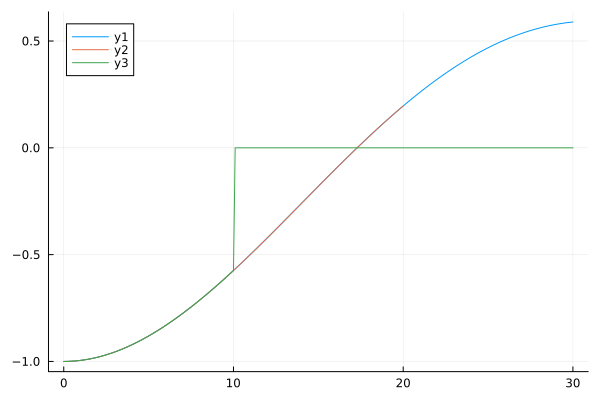

In [67]:
using JLD2
GRN_TEST = load_object("Grn_t_test.jld2")


Plots.plot(output_dict["total_times"],imag.(output_dict["Grn_t"]))
Plots.plot!(output_dict["total_times"][1:length(GRN_TEST)],imag.(GRN_TEST))
Plots.plot!(output_dict["total_times"],imag.(output_dict["Grn_t_test"]))